<a href="https://colab.research.google.com/github/emanuelmejia/course_time_series_python/blob/main/L04-Transform_Suavizamiento/notebooks/L04_1_Transform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import boxcox

# pip install correrlo solo una vez
!pip install sktime
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.base import ForecastingHorizon

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.5/37.5 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.1/165.1 kB 7.4 MB/s eta 0:00:00


#**Transformaciones de Calendario**

In [2]:
url = "https://raw.githubusercontent.com/ricardoscr/UW-Data-Science-Certificate/master/02-Methods/CADairyProduction.csv"
dfProd = pd.read_csv(url)

dfProd.head()

,Year,Month,Cotagecheese.Prod,Icecream.Prod,Milk.Prod,N.CA.Fat.Price,Month.Count,monthNumSqred,monthNumCubed
0,1995,Jan,4.370,51.595,2.112,0.9803,1,1,1
1,1995,Feb,3.695,56.086,1.932,0.8924,2,4,8
2,1995,Mar,4.538,68.453,2.162,0.8924,3,9,27
3,1995,Apr,4.280,65.722,2.130,0.8967,4,16,64
4,1995,May,4.470,73.730,2.227,0.8967,5,25,125


In [3]:
dfProd['Fecha'] = pd.period_range(start='1995-01', periods=len(dfProd), freq='M')
dfProd = dfProd.set_index('Fecha')
dfProd.index = dfProd.index.to_timestamp()
dfProd

,Year,Month,Cotagecheese.Prod,Icecream.Prod,Milk.Prod,N.CA.Fat.Price,Month.Count,monthNumSqred,monthNumCubed
Fecha,,,,,,,,,
1995-01-01,1995,Jan,4.370,51.595,2.112,0.9803,1,1,1
1995-02-01,1995,Feb,3.695,56.086,1.932,0.8924,2,4,8
1995-03-01,1995,Mar,4.538,68.453,2.162,0.8924,3,9,27
1995-04-01,1995,Apr,4.280,65.722,2.130,0.8967,4,16,64
1995-05-01,1995,May,4.470,73.730,2.227,0.8967,5,25,125
...,...,...,...,...,...,...,...,...,...
2013-08-01,2013,Aug,2.169,78.382,3.400,1.6273,224,50176,11239424
2013-09-01,2013,Sep,2.193,74.871,3.197,1.5519,225,50625,11390625
2013-10-01,2013,Oct,2.284,70.011,3.338,1.5566,226,51076,11543176


In [4]:
columna = 'Milk.Prod' # Columna de interés
nombre= 'Producción de Leche'

df = dfProd[columna].to_frame()
df.head()

,Milk.Prod
Fecha,
1995-01-01,2.112
1995-02-01,1.932
1995-03-01,2.162
1995-04-01,2.130
1995-05-01,2.227


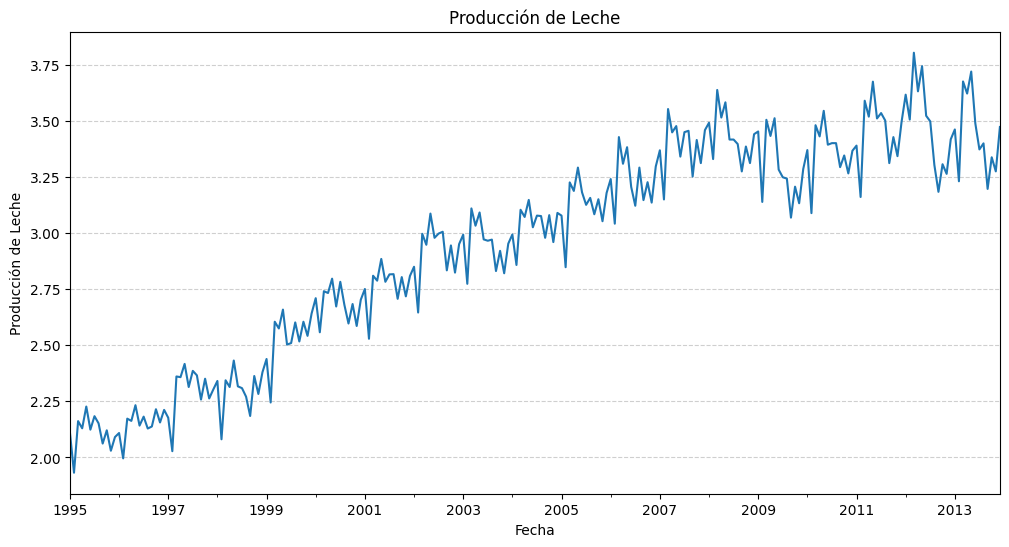

In [5]:
# Gráfico
plt.figure(figsize=(12, 6))
df[columna].plot()

# Etiquetas
plt.title(nombre)
plt.xlabel('Fecha')
plt.ylabel(nombre)

#Formato final
plt.grid(False, axis = 'x')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [6]:
df['PromDiario'] = df['Milk.Prod'] / df.index.days_in_month
df.head()

,Milk.Prod,PromDiario
Fecha,,
1995-01-01,2.112,0.068129
1995-02-01,1.932,0.069000
1995-03-01,2.162,0.069742
1995-04-01,2.130,0.071000
1995-05-01,2.227,0.071839


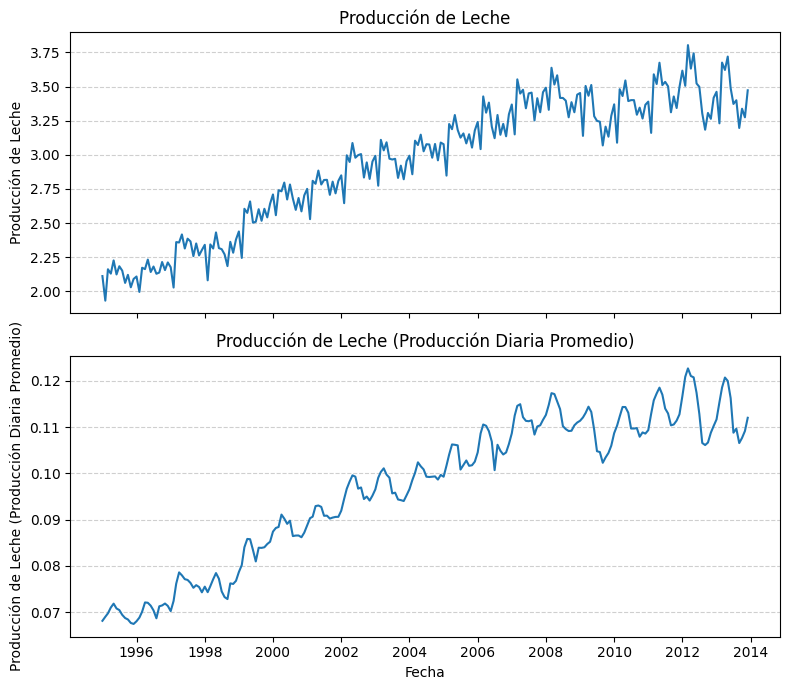

In [7]:
fig, ax = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

# Gráfico superior: Milk.Prod
ax[0].plot(df.index, df[columna])
ax[0].set_title(nombre)
ax[0].set_ylabel(nombre)
ax[0].grid(axis='y', linestyle='--', alpha=0.6)

# Gráfico inferior: PromDiario
ax[1].plot(df.index, df['PromDiario'])
ax[1].set_title(nombre + ' (Producción Diaria Promedio)')
ax[1].set_xlabel('Fecha')
ax[1].set_ylabel(nombre + ' (Producción Diaria Promedio)')
ax[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#**Transformaciones poblacionales**

In [8]:
# Subir archivo global_economy
from google.colab import files
files.upload()

Saving global_economy.csv to global_economy.csv


{'global_economy.csv': b'"unique_id","Code","ds","GDP","Growth","CPI","Imports","Exports","Population"\n"Afghanistan","AFG",1960,537777811.111111,NA,NA,7.02479336623182,4.13223321494422,8996351\n"Afghanistan","AFG",1961,548888895.555556,NA,NA,8.09716629841498,4.45344326574765,9166764\n"Afghanistan","AFG",1962,546666677.777778,NA,NA,9.34959330590257,4.87805112036481,9345868\n"Afghanistan","AFG",1963,751111191.111111,NA,NA,16.8639103340214,9.171601094149,9533954\n"Afghanistan","AFG",1964,800000044.444444,NA,NA,18.0555553858025,8.88889256172819,9731361\n"Afghanistan","AFG",1965,1006666637.77778,NA,NA,21.4128034842526,11.2582791310323,9938414\n"Afghanistan","AFG",1966,1399999966.66667,NA,NA,18.571428537415,8.57142877551021,10152331\n"Afghanistan","AFG",1967,1673333417.77778,NA,NA,14.2098270385479,6.77290842314672,10372630\n"Afghanistan","AFG",1968,1373333366.66667,NA,NA,15.2103564269331,8.89967664482985,10604346\n"Afghanistan","AFG",1969,1408888922.22222,NA,NA,14.9842272480072,10.094636985

In [9]:
dfEcon = pd.read_csv("/content/global_economy.csv")
dfEcon['Fecha'] = pd.to_datetime(dfEcon['ds'].astype(str), format='%Y')
dfEcon = dfEcon.set_index('Fecha')
dfEcon.index.name = 'Fecha'
dfEcon.head()

,unique_id,Code,ds,GDP,Growth,CPI,Imports,Exports,Population
Fecha,,,,,,,,,
1960-01-01,Afghanistan,AFG,1960,5.377778e+08,NaN,NaN,7.024793,4.132233,8996351.0
1961-01-01,Afghanistan,AFG,1961,5.488889e+08,NaN,NaN,8.097166,4.453443,9166764.0
1962-01-01,Afghanistan,AFG,1962,5.466667e+08,NaN,NaN,9.349593,4.878051,9345868.0
1963-01-01,Afghanistan,AFG,1963,7.511112e+08,NaN,NaN,16.863910,9.171601,9533954.0
1964-01-01,Afghanistan,AFG,1964,8.000000e+08,NaN,NaN,18.055555,8.888893,9731361.0


In [10]:
# Seleccionar únicamente datos de Qatar y quitar los que tengan valores NaN
df = dfEcon[dfEcon['unique_id'] == 'Qatar']
df = df.dropna(subset=['GDP', 'Population'])
df.head()

,unique_id,Code,ds,GDP,Growth,CPI,Imports,Exports,Population
Fecha,,,,,,,,,
1970-01-01,Qatar,QAT,1970,3.017913e+08,NaN,NaN,NaN,NaN,109514.0
1971-01-01,Qatar,QAT,1971,3.877001e+08,NaN,NaN,NaN,NaN,119424.0
1972-01-01,Qatar,QAT,1972,5.102599e+08,NaN,NaN,NaN,NaN,130534.0
1973-01-01,Qatar,QAT,1973,7.938844e+08,NaN,NaN,NaN,NaN,142241.0
1974-01-01,Qatar,QAT,1974,2.401403e+09,NaN,NaN,NaN,NaN,153704.0


In [11]:
# Crear columna adicional con el cálculo per cápita
df.loc[:, 'GDP per Capita'] = df['GDP'] / df['Population']
df.head()

,unique_id,Code,ds,GDP,Growth,CPI,Imports,Exports,Population,GDP per Capita
Fecha,,,,,,,,,,
1970-01-01,Qatar,QAT,1970,3.017913e+08,NaN,NaN,NaN,NaN,109514.0,2755.732617
1971-01-01,Qatar,QAT,1971,3.877001e+08,NaN,NaN,NaN,NaN,119424.0,3246.416836
1972-01-01,Qatar,QAT,1972,5.102599e+08,NaN,NaN,NaN,NaN,130534.0,3909.019418
1973-01-01,Qatar,QAT,1973,7.938844e+08,NaN,NaN,NaN,NaN,142241.0,5581.262562
1974-01-01,Qatar,QAT,1974,2.401403e+09,NaN,NaN,NaN,NaN,153704.0,15623.557145


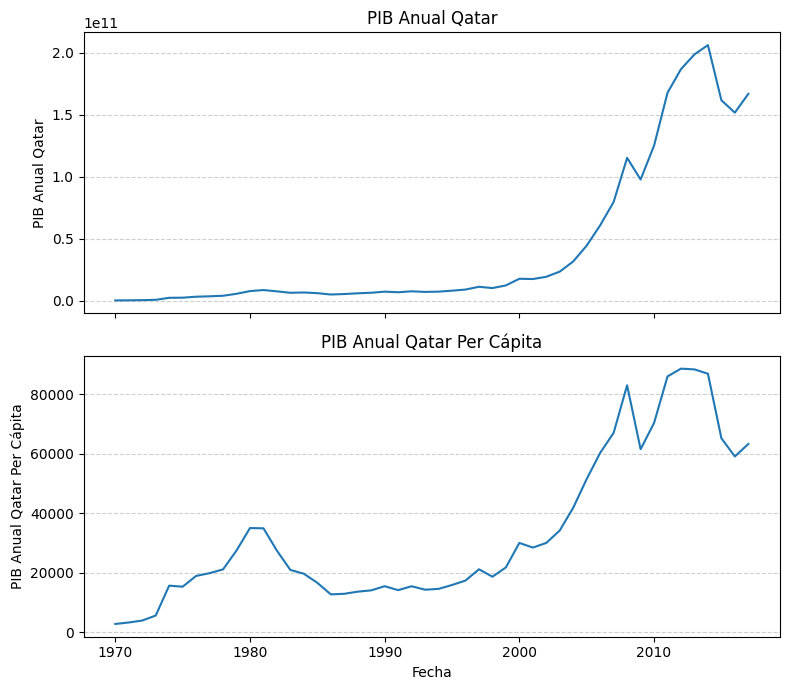

In [12]:
fig, ax = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

# Gráfico superior: Serie Original
ax[0].plot(df.index, df['GDP'])
ax[0].set_title('PIB Anual Qatar')
ax[0].set_ylabel('PIB Anual Qatar')
ax[0].grid(axis='y', linestyle='--', alpha=0.6)

# Gráfico inferior: Per capita
ax[1].plot(df.index, df['GDP per Capita'])
ax[1].set_title('PIB Anual Qatar Per Cápita')
ax[1].set_xlabel('Fecha')
ax[1].set_ylabel('PIB Anual Qatar Per Cápita')
ax[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# **Transformaciones por Índices Económicos**

In [13]:
# Subir archivo aus_retail
from google.colab import files
files.upload()

Saving aus_retail.csv to aus_retail.csv


{'aus_retail.csv': b'"State","Industry","Series ID","Month","Turnover"\n"Australian Capital Territory","Cafes, restaurants and catering services","A3349849A",1982-04-01,4.4\n"Australian Capital Territory","Cafes, restaurants and catering services","A3349849A",1982-05-01,3.4\n"Australian Capital Territory","Cafes, restaurants and catering services","A3349849A",1982-06-01,3.6\n"Australian Capital Territory","Cafes, restaurants and catering services","A3349849A",1982-07-01,4\n"Australian Capital Territory","Cafes, restaurants and catering services","A3349849A",1982-08-01,3.6\n"Australian Capital Territory","Cafes, restaurants and catering services","A3349849A",1982-09-01,4.2\n"Australian Capital Territory","Cafes, restaurants and catering services","A3349849A",1982-10-01,4.8\n"Australian Capital Territory","Cafes, restaurants and catering services","A3349849A",1982-11-01,5.4\n"Australian Capital Territory","Cafes, restaurants and catering services","A3349849A",1982-12-01,6.9\n"Australian 

In [14]:
dfFact = pd.read_csv("/content/aus_retail.csv")
dfFact['Fecha'] = pd.to_datetime(dfFact['Month'])
dfFact = dfFact.set_index('Fecha')
dfFact.index.name = 'Fecha'
dfFact.head()


,State,Industry,Series ID,Month,Turnover
Fecha,,,,,
1982-04-01,Australian Capital Territory,"Cafes, restaurants and catering services",A3349849A,1982-04-01,4.4
1982-05-01,Australian Capital Territory,"Cafes, restaurants and catering services",A3349849A,1982-05-01,3.4
1982-06-01,Australian Capital Territory,"Cafes, restaurants and catering services",A3349849A,1982-06-01,3.6
1982-07-01,Australian Capital Territory,"Cafes, restaurants and catering services",A3349849A,1982-07-01,4.0
1982-08-01,Australian Capital Territory,"Cafes, restaurants and catering services",A3349849A,1982-08-01,3.6


In [15]:
# Únicamente veremos facturación de una industria
df = dfFact[dfFact['Industry'] == 'Newspaper and book retailing']
df.head()

,State,Industry,Series ID,Month,Turnover
Fecha,,,,,
1982-04-01,Australian Capital Territory,Newspaper and book retailing,A3349773T,1982-04-01,2.3
1982-05-01,Australian Capital Territory,Newspaper and book retailing,A3349773T,1982-05-01,2.5
1982-06-01,Australian Capital Territory,Newspaper and book retailing,A3349773T,1982-06-01,2.3
1982-07-01,Australian Capital Territory,Newspaper and book retailing,A3349773T,1982-07-01,2.6
1982-08-01,Australian Capital Territory,Newspaper and book retailing,A3349773T,1982-08-01,2.6


In [16]:
# Tenemos varias filas con la misma fecha
# Queremos saber la facturación global
df.loc['1982-04']


,State,Industry,Series ID,Month,Turnover
Fecha,,,,,
1982-04-01,Australian Capital Territory,Newspaper and book retailing,A3349773T,1982-04-01,2.3
1982-04-01,New South Wales,Newspaper and book retailing,A3349556W,1982-04-01,50.4
1982-04-01,Queensland,Newspaper and book retailing,A3349348C,1982-04-01,18.4
1982-04-01,South Australia,Newspaper and book retailing,A3349575C,1982-04-01,8.1
1982-04-01,Tasmania,Newspaper and book retailing,A3349442X,1982-04-01,2.9
1982-04-01,Victoria,Newspaper and book retailing,A3349639C,1982-04-01,42.2
1982-04-01,Western Australia,Newspaper and book retailing,A3349822A,1982-04-01,9.7


In [17]:
# Agrupar sumando el turnover por cada fecha
df = df.groupby('Fecha')['Turnover'].sum().to_frame()
df.head()

,Turnover
Fecha,
1982-04-01,134.0
1982-05-01,133.6
1982-06-01,126.8
1982-07-01,128.4
1982-08-01,131.3


In [18]:
# Obtenemos índice de precios al consumidor desde otra tabla
# Ojo, subir global_economy antes
cpiAus = dfEcon[dfEcon['unique_id'] == 'Australia']['CPI'].to_frame()
cpiAus.head()

,CPI
Fecha,
1960-01-01,7.960458
1961-01-01,8.142560
1962-01-01,8.116545
1963-01-01,8.168574
1964-01-01,8.402706


In [19]:
# Unir los datos de CPI a nuestro dataframe original
df = df.join(cpiAus, how='inner')
df.tail(15)

,Turnover,CPI
Fecha,,
2003-01-01,301.2,82.154006
2004-01-01,327.0,84.079084
2005-01-01,359.2,86.342352
2006-01-01,341.4,89.412071
2007-01-01,333.9,91.493236
2008-01-01,385.8,95.473465
2009-01-01,388.6,97.164412
2010-01-01,373.3,100.000000
2011-01-01,413.2,103.303850


In [20]:
# Realizar ajuste inflacionario
df.loc[:, 'Adj Turnover'] = (df['Turnover'] / df['CPI'])*100
df.tail(15)

,Turnover,CPI,Adj Turnover
Fecha,,,
2003-01-01,301.2,82.154006,366.628499
2004-01-01,327.0,84.079084,388.919554
2005-01-01,359.2,86.342352,416.018319
2006-01-01,341.4,89.412071,381.827640
2007-01-01,333.9,91.493236,364.945010
2008-01-01,385.8,95.473465,404.091335
2009-01-01,388.6,97.164412,399.940669
2010-01-01,373.3,100.000000,373.300000
2011-01-01,413.2,103.303850,399.985092


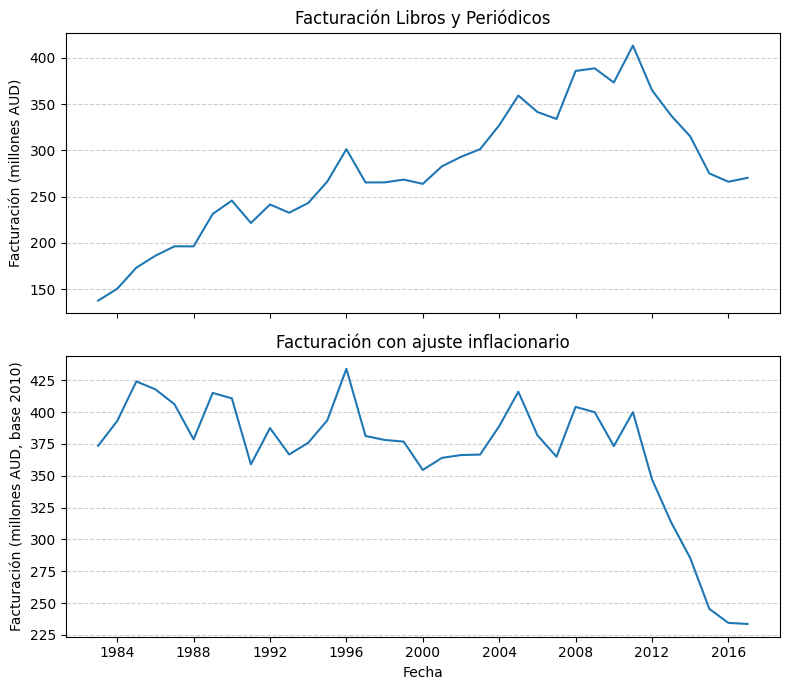

In [21]:
fig, ax = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

# Gráfico superior: Serie Original
ax[0].plot(df.index, df['Turnover'])
ax[0].set_title('Facturación Libros y Periódicos')
ax[0].set_ylabel('Facturación (millones AUD)')
ax[0].grid(axis='y', linestyle='--', alpha=0.6)

# Gráfico inferior: Ajuste inflacionario
ax[1].plot(df.index, df['Adj Turnover'])
ax[1].set_title('Facturación con ajuste inflacionario')
ax[1].set_xlabel('Fecha')
ax[1].set_ylabel('Facturación (millones AUD, base 2010)')
ax[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# **Transformaciones Logarítmicas**

In [22]:
# Subir archivo pas
from google.colab import files
files.upload()

Saving pas.csv to pas.csv


{'pas.csv': b'Periodo,Pasajeros\r\n1,112\r\n2,118\r\n3,132\r\n4,129\r\n5,121\r\n6,135\r\n7,148\r\n8,148\r\n9,136\r\n10,119\r\n11,104\r\n12,118\r\n13,115\r\n14,126\r\n15,141\r\n16,135\r\n17,125\r\n18,149\r\n19,170\r\n20,170\r\n21,158\r\n22,133\r\n23,114\r\n24,140\r\n25,145\r\n26,150\r\n27,178\r\n28,163\r\n29,172\r\n30,178\r\n31,199\r\n32,199\r\n33,184\r\n34,162\r\n35,146\r\n36,166\r\n37,171\r\n38,180\r\n39,193\r\n40,181\r\n41,183\r\n42,218\r\n43,230\r\n44,242\r\n45,209\r\n46,191\r\n47,172\r\n48,194\r\n49,196\r\n50,196\r\n51,236\r\n52,235\r\n53,229\r\n54,243\r\n55,264\r\n56,272\r\n57,237\r\n58,211\r\n59,180\r\n60,201\r\n61,204\r\n62,188\r\n63,235\r\n64,227\r\n65,234\r\n66,264\r\n67,302\r\n68,293\r\n69,259\r\n70,229\r\n71,203\r\n72,229\r\n73,242\r\n74,233\r\n75,267\r\n76,269\r\n77,270\r\n78,315\r\n79,364\r\n80,347\r\n81,312\r\n82,274\r\n83,237\r\n84,278\r\n85,284\r\n86,277\r\n87,317\r\n88,313\r\n89,318\r\n90,374\r\n91,413\r\n92,405\r\n93,355\r\n94,306\r\n95,271\r\n96,306\r\n97,315\r\n98,3

In [23]:
df = pd.read_csv("/content/pas.csv")
df

,Periodo,Pasajeros
0,1,112
1,2,118
2,3,132
3,4,129
4,5,121
...,...,...
139,140,606
140,141,508
141,142,461
142,143,390


In [24]:
df['Fecha'] = pd.period_range(start='1949-01', periods=len(df), freq='M')
df = df.set_index('Fecha')
df = df.drop(columns=['Periodo'])
# Convertir a índice Datetime para compatibilidad con descomposición
df.index = df.index.to_timestamp()
df.head()

,Pasajeros
Fecha,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [25]:
# Generar columna con logaritmo de pasajeros
df['logPasajeros'] = np.log(df['Pasajeros'])
df.head()

,Pasajeros,logPasajeros
Fecha,,
1949-01-01,112,4.718499
1949-02-01,118,4.770685
1949-03-01,132,4.882802
1949-04-01,129,4.859812
1949-05-01,121,4.795791


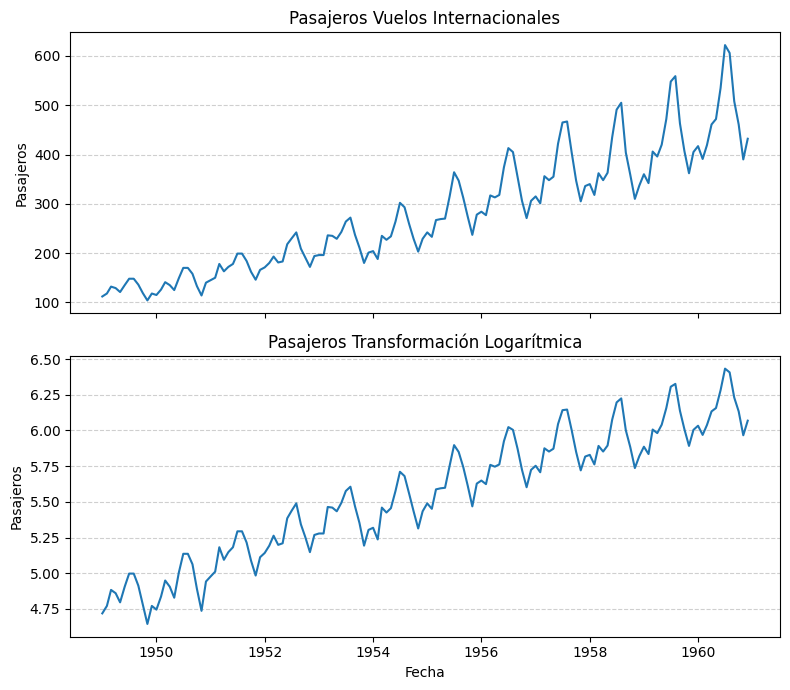

In [26]:
fig, ax = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

# Gráfico superior: Serie Original
ax[0].plot(df.index, df['Pasajeros'])
ax[0].set_title('Pasajeros Vuelos Internacionales')
ax[0].set_ylabel('Pasajeros')
ax[0].grid(axis='y', linestyle='--', alpha=0.6)

# Gráfico inferior: Transformación Logarítmica
ax[1].plot(df.index, df['logPasajeros'])
ax[1].set_title('Pasajeros Transformación Logarítmica')
ax[1].set_xlabel('Fecha')
ax[1].set_ylabel('Pasajeros')
ax[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [27]:
# Aplicar transformación Box-Cox, encontrando lambda automáticamente
boxcox(df['Pasajeros'])

(array([ 6.82749067,  6.93282287,  7.16189218,  7.11461145,  6.98378751,
         7.20826611,  7.39959866,  7.39959866,  7.22352903,  6.94993252,
         6.67930171,  6.93282287,  6.88074211,  7.06638446,  7.29843916,
         7.20826611,  7.05009131,  7.41371557,  7.69297831,  7.69297831,
         7.53726079,  7.17744904,  6.86312451,  7.28364025,  7.35675479,
         7.42775199,  7.79166378,  7.60332755,  7.71801471,  7.79166378,
         8.0338004 ,  8.0338004 ,  7.86322731,  7.59025368,  7.37111931,
         7.64214327,  7.7055277 ,  7.81574364,  7.96693093,  7.8276982 ,
         7.85143946,  8.2347861 ,  8.35415885,  8.46833829,  8.1415253 ,
         7.94424732,  7.71801471,  7.97819773,  8.00058368,  8.00058368,
         8.41186693,  8.40233638,  8.34441642,  8.47763395,  8.66568713,
         8.73398382,  8.42136314,  8.16254151,  7.81574364,  8.05570864,
         8.08822528,  7.90983951,  8.40233638,  8.32482233,  8.39277121,
         8.66568713,  8.97573799,  8.9054447 ,  8.6

In [28]:
# Guardamos la tabla y el valor de lambda
df['boxcoxPasajeros'], lambdaPas = boxcox(df['Pasajeros'])

print(f"Lambda (Box-Cox) encontrado para datos Pasajeros: {lambdaPas:.4f}")
df.head()

Lambda (Box-Cox) encontrado para datos Pasajeros: 0.1480


,Pasajeros,logPasajeros,boxcoxPasajeros
Fecha,,,
1949-01-01,112,4.718499,6.827491
1949-02-01,118,4.770685,6.932823
1949-03-01,132,4.882802,7.161892
1949-04-01,129,4.859812,7.114611
1949-05-01,121,4.795791,6.983788


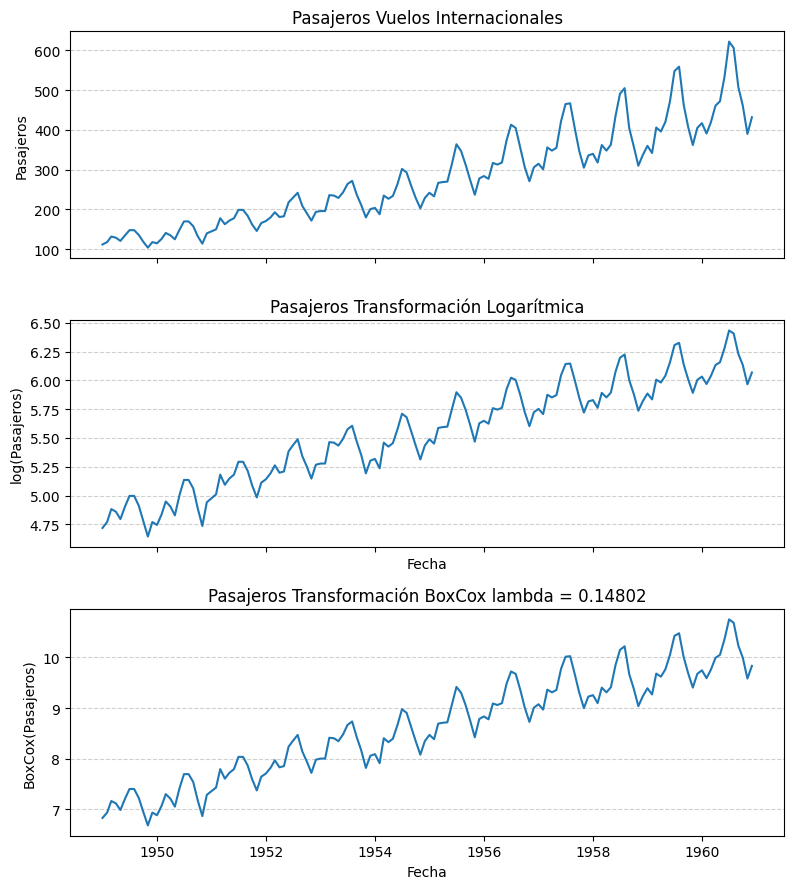

In [29]:
fig, ax = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

# Gráfico superior: Serie Original
ax[0].plot(df.index, df['Pasajeros'])
ax[0].set_title('Pasajeros Vuelos Internacionales')
ax[0].set_ylabel('Pasajeros')
ax[0].grid(axis='y', linestyle='--', alpha=0.6)

# Gráfico medio: Transformación Logarítmica
ax[1].plot(df.index, df['logPasajeros'])
ax[1].set_title('Pasajeros Transformación Logarítmica')
ax[1].set_xlabel('Fecha')
ax[1].set_ylabel('log(Pasajeros)')
ax[1].grid(axis='y', linestyle='--', alpha=0.6)

# Gráfico inferior: Transformación BoxCox
ax[2].plot(df.index, df['boxcoxPasajeros'])
ax[2].set_title('Pasajeros Transformación BoxCox lambda = ' + str(round(lambdaPas,5)))
ax[2].set_xlabel('Fecha')
ax[2].set_ylabel('BoxCox(Pasajeros)')
ax[2].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# **Pronósticos**

In [30]:
# Subir archivo eggs.csv
from google.colab import files
files.upload()

Saving eggs.csv to eggs.csv


{'eggs.csv': b'ds,y,unique_id\n1900-01-01,276.79,eggs\n1901-01-01,315.42,eggs\n1902-01-01,314.87,eggs\n1903-01-01,321.25,eggs\n1904-01-01,314.54,eggs\n1905-01-01,317.92,eggs\n1906-01-01,303.39,eggs\n1907-01-01,288.62,eggs\n1908-01-01,292.44,eggs\n1909-01-01,320.92,eggs\n1910-01-01,323.38,eggs\n1911-01-01,270.77,eggs\n1912-01-01,301.77,eggs\n1913-01-01,282.99,eggs\n1914-01-01,295.06,eggs\n1915-01-01,276.47,eggs\n1916-01-01,292.8,eggs\n1917-01-01,358.78,eggs\n1918-01-01,345.82,eggs\n1919-01-01,345.42,eggs\n1920-01-01,314.1,eggs\n1921-01-01,228.74,eggs\n1922-01-01,215.76,eggs\n1923-01-01,224.67,eggs\n1924-01-01,225.93,eggs\n1925-01-01,250.87,eggs\n1926-01-01,236.24,eggs\n1927-01-01,209.12,eggs\n1928-01-01,237.31,eggs\n1929-01-01,251.67,eggs\n1930-01-01,205.36,eggs\n1931-01-01,167.21,eggs\n1932-01-01,150.42,eggs\n1933-01-01,154.09,eggs\n1934-01-01,183.67,eggs\n1935-01-01,246.66,eggs\n1936-01-01,227.58,eggs\n1937-01-01,214.6,eggs\n1938-01-01,208.41,eggs\n1939-01-01,181.21,eggs\n1940-01-01,1

In [31]:
dfEggs = pd.read_csv("/content/eggs.csv")
dfEggs.head()

,ds,y,unique_id
0,1900-01-01,276.79,eggs
1,1901-01-01,315.42,eggs
2,1902-01-01,314.87,eggs
3,1903-01-01,321.25,eggs
4,1904-01-01,314.54,eggs


In [32]:
dfEggs['Fecha'] = pd.period_range(start='1900-01', periods=len(dfEggs), freq='Y')
dfEggs = dfEggs.set_index('Fecha')
dfEggs.index = dfEggs.index.to_timestamp()
df = dfEggs.drop(columns=['ds', 'unique_id'])
df = df.rename(columns={'y': 'huevo'})
df.head()

,huevo
Fecha,
1900-01-01,276.79
1901-01-01,315.42
1902-01-01,314.87
1903-01-01,321.25
1904-01-01,314.54


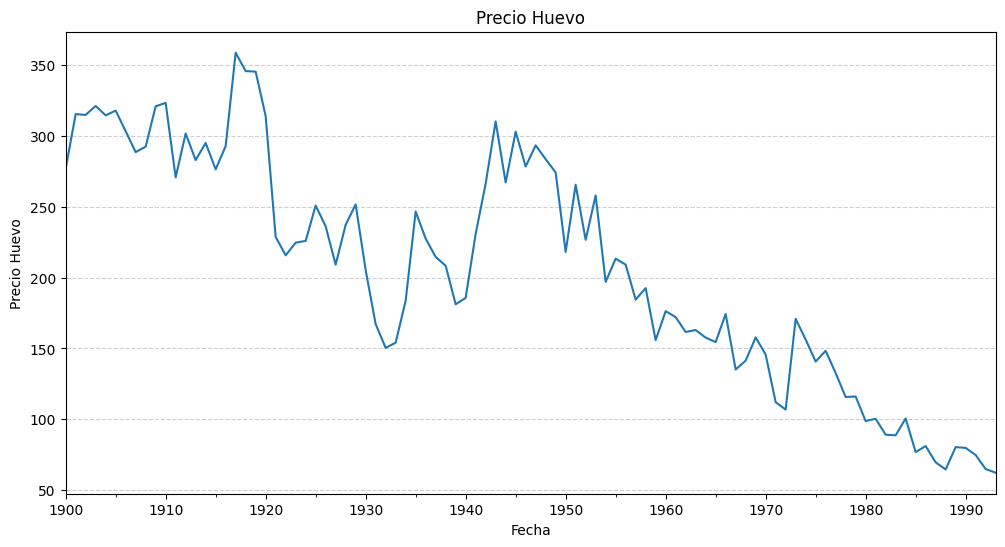

In [33]:
# Gráfico
plt.figure(figsize=(12, 6))
df['huevo'].plot()

# Etiquetas
plt.title('Precio Huevo')
plt.xlabel('Fecha')
plt.ylabel('Precio Huevo')

#Formato final
plt.grid(False, axis = 'x')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [34]:
# Crear columna para logaritmo natural
df['logHuevo'] = np.log(df['huevo'])

# Crear columna para transformación Box-Cox, encontrando lambda automáticamente
df['boxcoxHuevo'], lambdaHuevo = boxcox(df['huevo'])

print(f"Lambda (Box-Cox) encontrado para 'huevo': {lambdaHuevo:.4f}")
df.head()

Lambda (Box-Cox) encontrado para 'huevo': 0.8744


,huevo,logHuevo,boxcoxHuevo
Fecha,,,
1900-01-01,276.79,5.623259,155.089568
1901-01-01,315.42,5.753905,173.997321
1902-01-01,314.87,5.752160,173.730244
1903-01-01,321.25,5.772220,176.824761
1904-01-01,314.54,5.751111,173.569970


In [35]:
# Definir horizonte de forecasting 50 pasos
pasos = 30
fh = ForecastingHorizon(np.arange(1, pasos + 1))

In [36]:
# Forecast utilizando drift para logaritmo
forecasterLog = NaiveForecaster(strategy="drift")
forecasterLog.fit(df['logHuevo'])
predLog = forecasterLog.predict(fh=fh)

# Transformación inversa del log
predLogInv = np.exp(predLog)

In [37]:
# Forecast utilizando drift para boxcox
forecasterBoxcox = NaiveForecaster(strategy="drift")
forecasterBoxcox.fit(df['boxcoxHuevo'])
predBoxcox = forecasterBoxcox.predict(fh=fh)

# Transformación inversa boxcox
predBoxcoxInv = (lambdaHuevo * predBoxcox + 1)**(1/lambdaHuevo)

In [38]:
# Crear indice de fechas para forecasts
ultFecha = df.index[-1]
forecast_dates = pd.date_range(start=ultFecha, periods=pasos + 1, freq='YS')[1:]

# Combinar forecast en un df
forecast_df = pd.DataFrame({
    'logForecast': predLogInv,
    'boxcoxForecast': predBoxcoxInv
})

forecast_df.index = forecast_dates

forecast_df.head()

,logForecast,boxcoxForecast
1994-01-01,61.279118,60.217804
1995-01-01,60.304003,58.174354
1996-01-01,59.344406,56.139878
1997-01-01,58.400078,54.114620
1998-01-01,57.470776,52.098836


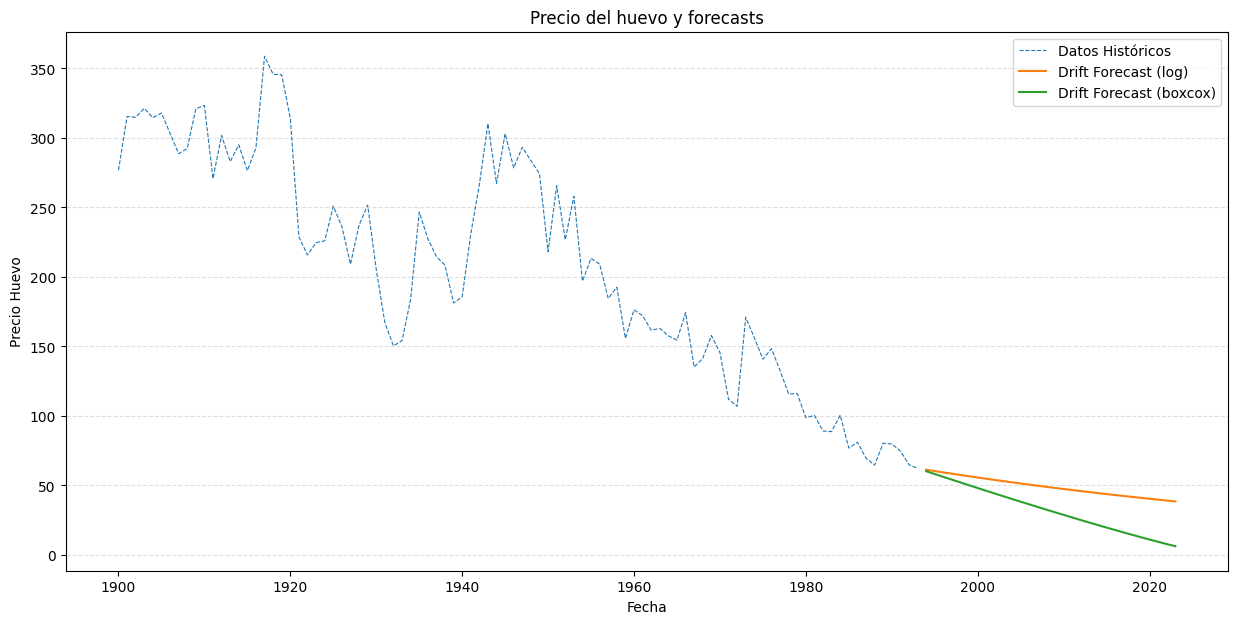

In [39]:
# Gráfico de serie con forecasts
plt.figure(figsize=(15, 7))
plt.plot(df['huevo'], label='Datos Históricos', linestyle='--', lw =0.8)

plt.plot(forecast_dates, forecast_df['logForecast'], label='Drift Forecast (log)')
plt.plot(forecast_dates, forecast_df['boxcoxForecast'], label='Drift Forecast (boxcox)')

plt.title('Precio del huevo y forecasts')
plt.xlabel('Fecha')
plt.ylabel('Precio Huevo')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()